The stochastic gradient descent code is tested on the simple task of finding the xor of two binary gates. Both sigmoid and ReLU are tested.

Minibatch/full gradient descent is also tested

In [1]:
%load_ext autoreload
%autoreload 2
from Network import Network, Layer
import torch
import random
import matplotlib.pyplot as plt



In [2]:
# SGD - only use one input
xor_network = Network()
xor_network.layers.append(Layer(2, 8))
xor_network.layers.append(Layer(8, 8))
xor_network.layers.append(Layer(8, 2, activation_function=torch.nn.Identity()))

inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(3000):
    j = random.randint(0,3)
    xor_network.calculate_with_gradient(inputs[j], outputs[j])
    xor_network.update_weights(0.05)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9964, 0.0036]])
tensor([[0.0014, 0.9986]])
tensor([[0.0053, 0.9947]])
tensor([[0.9981, 0.0019]])


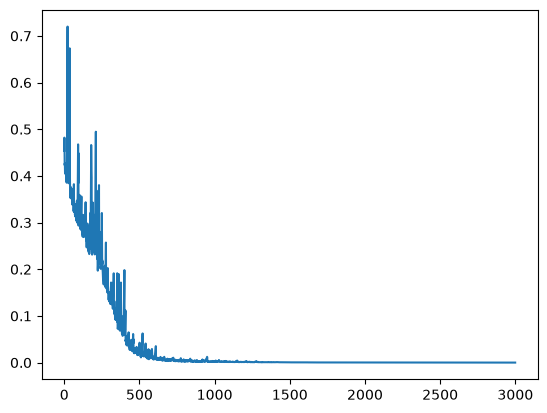

In [3]:
plt.plot(range(len(mse_errors)), mse_errors)

In [42]:
# Same as above but for sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2, 4, torch.sigmoid))
xor_network.layers.append(Layer(4, 4, torch.sigmoid))
xor_network.layers.append(Layer(4, 4, torch.sigmoid))
xor_network.layers.append(Layer(4, 2, torch.nn.Identity()))

inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(3000):
    for j in random.choices([0, 1, 2, 3], k=4):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])

    for j in range(4):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])

    
    xor_network.update_weights(2)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[9.9920e-01, 7.9612e-04]])
tensor([[5.1145e-04, 9.9949e-01]])
tensor([[3.1372e-04, 9.9969e-01]])
tensor([[9.9931e-01, 6.8713e-04]])


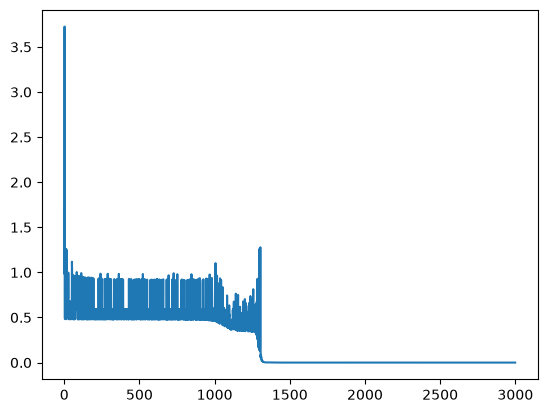

In [43]:
plt.plot(range(len(mse_errors)), mse_errors)

In [6]:
# Full gradient descent
xor_network = Network()
xor_network.layers.append(Layer(2,4))
xor_network.layers.append(Layer(4,4))
xor_network.layers.append(Layer(4,4))
xor_network.layers.append(Layer(4,2, torch.nn.Identity()))

inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(500):
    for j in range(4):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])

    xor_network.update_weights(0.2)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9989, 0.0011]])
tensor([[0.0035, 0.9965]])
tensor([[0.0016, 0.9984]])
tensor([[0.9987, 0.0013]])


In [7]:
values = torch.tensor([[0,1]])

for layer in xor_network.layers:
    values = layer.calculate(values)
    print(values)

tensor([[0.8164, 0.9424, 1.6046, 0.0000]])
tensor([[0.8724, 0.7000, 0.1878, 0.7901]])
tensor([[0.0000, 0.0000, 1.7056, 0.6407]])
tensor([[-3.8543,  1.8014]])


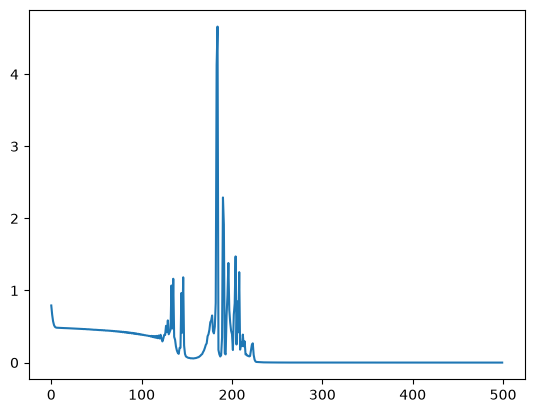

In [8]:
plt.plot(range(len(mse_errors)), mse_errors)

In [9]:
xor_network

Neural network with 4 layers.
Has layers: 
Layer with 2 inputs and 4 outputs.
tensor([[-0.0740, -0.5870, -0.2066,  0.9833],
        [ 0.7775,  0.8664,  1.4710, -2.2148],
        [ 0.0389,  0.0760,  0.1337, -0.4703]])
Layer with 4 inputs and 4 outputs.
tensor([[ 0.7711,  1.0369,  0.9321, -0.7327],
        [-0.7664,  1.4765, -0.9444,  0.4178],
        [ 0.1403, -1.2568, -0.8108,  0.0979],
        [-0.1186,  1.3089, -1.9167,  0.2894],
        [ 0.7400,  0.4787,  1.6178,  0.8374]])
Layer with 4 inputs and 4 outputs.
tensor([[ 0.7108, -0.3597,  0.1929, -0.5077],
        [-1.7796, -0.0685,  0.7096,  1.1089],
        [ 2.2241, -0.2771, -0.6668,  0.1530],
        [-0.1999,  0.2580,  0.6114, -0.0770],
        [ 0.3522, -0.2526,  0.6827,  0.3395]])
Layer with 4 inputs and 2 outputs.
tensor([[ 2.0552, -1.2716],
        [-0.2601,  0.0148],
        [-1.3859,  0.5211],
        [-0.4238,  0.4727],
        [-1.2189,  0.6097]])

In [10]:
# Same again but with sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2,4, torch.sigmoid))
xor_network.layers.append(Layer(4,4, torch.sigmoid))
xor_network.layers.append(Layer(4,4, torch.sigmoid))
xor_network.layers.append(Layer(4,2, torch.nn.Identity()))
inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(3000):
    for j in range(4):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])

    xor_network.update_weights(1)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9985, 0.0015]])
tensor([[0.0011, 0.9989]])
tensor([[0.0011, 0.9989]])
tensor([[0.9987, 0.0013]])


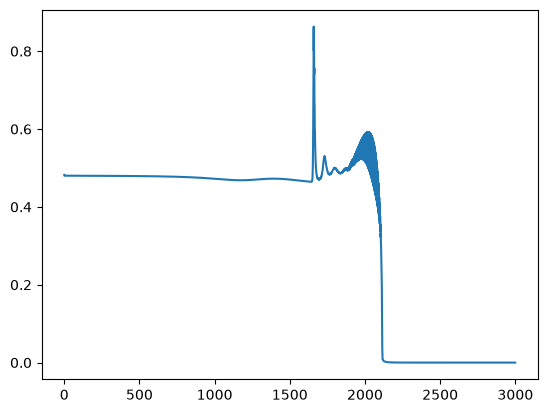

In [11]:
plt.plot(range(len(mse_errors)), mse_errors)